# Feature Engineering

In [2]:
import pandas as pd
import numpy as np
from pathlib import Path
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", None)

train = pd.read_csv("../data/processed/cleaned_train.csv")
test = pd.read_csv("../data/processed/cleaned_test.csv")

print("Train shape:", train.shape)
print("Test shape:", test.shape)



Train shape: (1460, 80)
Test shape: (1459, 79)


In [3]:
target = "SalePrice"

y = train[target]
train_features = train.drop(columns=[target])

print("Features shape:", train_features.shape)
print("Target shape:", y.shape)


Features shape: (1460, 79)
Target shape: (1460,)


In [4]:
train_features["Dataset"] = "train"
test["Dataset"] = "test"

combined = pd.concat([train_features, test], axis=0, ignore_index=True)

print("Combined shape:", combined.shape)


Combined shape: (2919, 80)


## Create new features


In [5]:
combined["TotalSF"] = combined["TotalBsmtSF"] + combined["1stFlrSF"] + combined["2ndFlrSF"]
combined["TotalBathrooms"] = (
    combined["FullBath"] 
    + 0.5 * combined["HalfBath"] 
    + combined["BsmtFullBath"] 
    + 0.5 * combined["BsmtHalfBath"]
)
combined["HouseAge"] = combined["YrSold"] - combined["YearBuilt"]
combined["RemodelAge"] = combined["YrSold"] - combined["YearRemodAdd"]
combined["HasGarage"] = (combined["GarageArea"] > 0).astype(int)
combined["HasBasement"] = (combined["TotalBsmtSF"] > 0).astype(int)
combined["HasFireplace"] = (combined["Fireplaces"] > 0).astype(int)

combined[["TotalSF", "TotalBathrooms", "HouseAge", "RemodelAge", "HasGarage", "HasBasement", "HasFireplace"]].head()


,TotalSF,TotalBathrooms,HouseAge,RemodelAge,HasGarage,HasBasement,HasFireplace
0,2566.0,3.5,5,5,1,1,0
1,2524.0,2.5,31,31,1,1,1
2,2706.0,3.5,7,6,1,1,1
3,2473.0,2.0,91,36,1,1,1
4,3343.0,3.5,8,8,1,1,1


## Fix impossible negative ages if any

In [6]:
combined["HouseAge"] = combined["HouseAge"].clip(lower=0)
combined["RemodelAge"] = combined["RemodelAge"].clip(lower=0)

print("Minimum HouseAge:", combined["HouseAge"].min())
print("Minimum RemodelAge:", combined["RemodelAge"].min())


Minimum HouseAge: 0
Minimum RemodelAge: 0


## Transform target variable

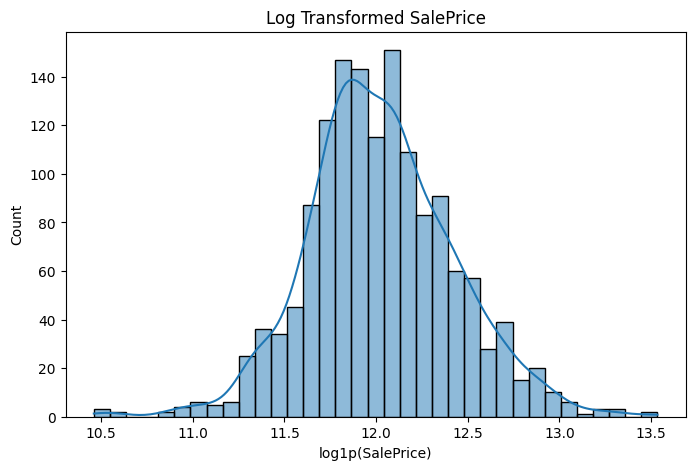

Original skewness: 1.8828757597682129
Log-transformed skewness: 0.12134661989685333


In [7]:
y_log = np.log1p(y)

plt.figure(figsize=(8, 5))
sns.histplot(y_log, kde=True)
plt.title("Log Transformed SalePrice")
plt.xlabel("log1p(SalePrice)")
plt.show()

print("Original skewness:", y.skew())
print("Log-transformed skewness:", y_log.skew())


## One-hot encode categorical variables

In [8]:
combined_encoded = pd.get_dummies(combined, drop_first=True)

print("Shape after encoding:", combined_encoded.shape)
combined_encoded.head()


Shape after encoding: (2919, 252)


,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,BsmtUnfSF,TotalBsmtSF,1stFlrSF,2ndFlrSF,LowQualFinSF,GrLivArea,BsmtFullBath,BsmtHalfBath,FullBath,HalfBath,BedroomAbvGr,KitchenAbvGr,TotRmsAbvGrd,Fireplaces,GarageYrBlt,GarageCars,GarageArea,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,TotalSF,TotalBathrooms,HouseAge,RemodelAge,HasGarage,HasBasement,HasFireplace,MSZoning_FV,MSZoning_RH,MSZoning_RL,MSZoning_RM,Street_Pave,Alley_Pave,LotShape_IR2,LotShape_IR3,LotShape_Reg,LandContour_HLS,LandContour_Low,LandContour_Lvl,Utilities_NoSeWa,LotConfig_CulDSac,LotConfig_FR2,LotConfig_FR3,LotConfig_Inside,LandSlope_Mod,LandSlope_Sev,Neighborhood_Blueste,Neighborhood_BrDale,Neighborhood_BrkSide,Neighborhood_ClearCr,Neighborhood_CollgCr,Neighborhood_Crawfor,Neighborhood_Edwards,Neighborhood_Gilbert,Neighborhood_IDOTRR,Neighborhood_MeadowV,Neighborhood_Mitchel,Neighborhood_NAmes,Neighborhood_NPkVill,Neighborhood_NWAmes,Neighborhood_NoRidge,Neighborhood_NridgHt,Neighborhood_OldTown,Neighborhood_SWISU,Neighborhood_Sawyer,Neighborhood_SawyerW,Neighborhood_Somerst,Neighborhood_StoneBr,Neighborhood_Timber,Neighborhood_Veenker,Condition1_Feedr,Condition1_Norm,Condition1_PosA,Condition1_PosN,Condition1_RRAe,Condition1_RRAn,Condition1_RRNe,Condition1_RRNn,Condition2_Feedr,Condition2_Norm,Condition2_PosA,Condition2_PosN,Condition2_RRAe,Condition2_RRAn,Condition2_RRNn,BldgType_2fmCon,BldgType_Duplex,BldgType_Twnhs,BldgType_TwnhsE,HouseStyle_1.5Unf,HouseStyle_1Story,HouseStyle_2.5Fin,HouseStyle_2.5Unf,HouseStyle_2Story,HouseStyle_SFoyer,HouseStyle_SLvl,RoofStyle_Gable,RoofStyle_Gambrel,RoofStyle_Hip,RoofStyle_Mansard,RoofStyle_Shed,RoofMatl_CompShg,RoofMatl_Membran,RoofMatl_Metal,RoofMatl_Roll,RoofMatl_Tar&Grv,RoofMatl_WdShake,RoofMatl_WdShngl,Exterior1st_AsphShn,Exterior1st_BrkComm,Exterior1st_BrkFace,Exterior1st_CBlock,Exterior1st_CemntBd,Exterior1st_HdBoard,Exterior1st_ImStucc,Exterior1st_MetalSd,Exterior1st_Plywood,Exterior1st_Stone,Exterior1st_Stucco,Exterior1st_VinylSd,Exterior1st_Wd Sdng,Exterior1st_WdShing,Exterior2nd_AsphShn,Exterior2nd_Brk Cmn,Exterior2nd_BrkFace,Exterior2nd_CBlock,Exterior2nd_CmentBd,Exterior2nd_HdBoard,Exterior2nd_ImStucc,Exterior2nd_MetalSd,Exterior2nd_Other,Exterior2nd_Plywood,Exterior2nd_Stone,Exterior2nd_Stucco,Exterior2nd_VinylSd,Exterior2nd_Wd Sdng,Exterior2nd_Wd Shng,MasVnrType_BrkFace,MasVnrType_Stone,ExterQual_Fa,ExterQual_Gd,ExterQual_TA,ExterCond_Fa,ExterCond_Gd,ExterCond_Po,ExterCond_TA,Foundation_CBlock,Foundation_PConc,Foundation_Slab,Foundation_Stone,Foundation_Wood,BsmtQual_Fa,BsmtQual_Gd,BsmtQual_TA,BsmtCond_Gd,BsmtCond_Po,BsmtCond_TA,BsmtExposure_Gd,BsmtExposure_Mn,BsmtExposure_No,BsmtFinType1_BLQ,BsmtFinType1_GLQ,BsmtFinType1_LwQ,BsmtFinType1_Rec,BsmtFinType1_Unf,BsmtFinType2_BLQ,BsmtFinType2_GLQ,BsmtFinType2_LwQ,BsmtFinType2_Rec,BsmtFinType2_Unf,Heating_GasA,Heating_GasW,Heating_Grav,Heating_OthW,Heating_Wall,HeatingQC_Fa,HeatingQC_Gd,HeatingQC_Po,HeatingQC_TA,CentralAir_Y,Electrical_FuseF,Electrical_FuseP,Electrical_Mix,Electrical_SBrkr,KitchenQual_Fa,KitchenQual_Gd,KitchenQual_TA,Functional_Maj2,Functional_Min1,Functional_Min2,Functional_Mod,Functional_Sev,Functional_Typ,FireplaceQu_Fa,FireplaceQu_Gd,FireplaceQu_Po,FireplaceQu_TA,GarageType_Attchd,GarageType_Basment,GarageType_BuiltIn,GarageType_CarPort,GarageType_Detchd,GarageFinish_RFn,GarageFinish_Unf,GarageQual_Fa,GarageQual_Gd,GarageQual_Po,GarageQual_TA,GarageCond_Fa,GarageCond_Gd,GarageCond_Po,GarageCond_TA,PavedDrive_P,PavedDrive_Y,PoolQC_Fa,PoolQC_Gd,Fence_GdWo,Fence_MnPrv,Fence_MnWw,MiscFeature_Othr,MiscFeature_Shed,MiscFeature_TenC,SaleType_CWD,SaleType_Con,SaleType_ConLD,SaleType_ConLI,SaleType_ConLw,SaleType_New,SaleType_Oth,SaleType_WD,SaleCondition_AdjLand,SaleCondition_Alloca,SaleCondition_Family,SaleCondition_Normal,SaleCondition_Partial,Dataset_train
0,60,65.0,8450,7,5,2003,2003,196.0,706.0,0.0,150.0,856.0,856,854,0,1710,1.0,0.0

## Split engineered data back into train and test

In [9]:
train_engineered = combined_encoded[combined_encoded["Dataset_train"] == True].drop(columns=["Dataset_train"])
test_engineered = combined_encoded[combined_encoded["Dataset_train"] == False].drop(columns=["Dataset_train"])

train_engineered[target] = y.values
train_engineered["SalePrice_Log"] = y_log.values

print("Engineered train shape:", train_engineered.shape)
print("Engineered test shape:", test_engineered.shape)


Engineered train shape: (1460, 253)
Engineered test shape: (1459, 251)


## Save engineered datasets

In [10]:
Path("../data/processed").mkdir(parents=True, exist_ok=True)

train_engineered.to_csv("../data/processed/engineered_train.csv", index=False)
test_engineered.to_csv("../data/processed/engineered_test.csv", index=False)

print("Saved engineered_train.csv and engineered_test.csv successfully.")


Saved engineered_train.csv and engineered_test.csv successfully.


## Notes
- Missing values are handled.
- Categorical variables are encoded.
- Useful features are created.
- Target has both original and log-transformed versions.
